In [1]:
### Load Libraries
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

import tensorflow as tf
tf.config.set_visible_devices([], 'GPU')   # works even if TF already imported
tf.keras.backend.clear_session()

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import AdamW, Adam
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau


print("finished")

2025-10-21 20:35:10.725863: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-10-21 20:35:10.725939: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-10-21 20:35:10.728092: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-10-21 20:35:10.738796: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-21 20:35:11.814559: W tensorflow/compiler/tf2

finished


Outlier rate (IQR): 0.0%
skew=-0.05, kurtosis=-1.40


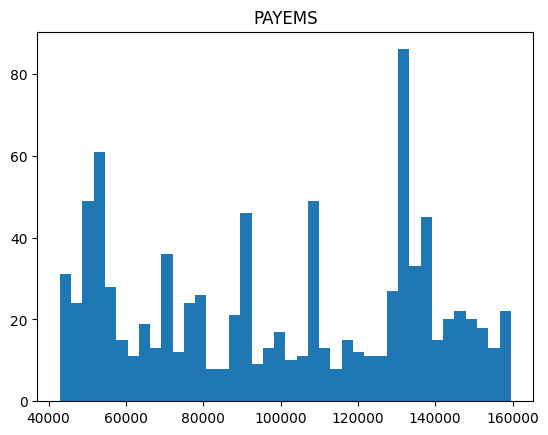

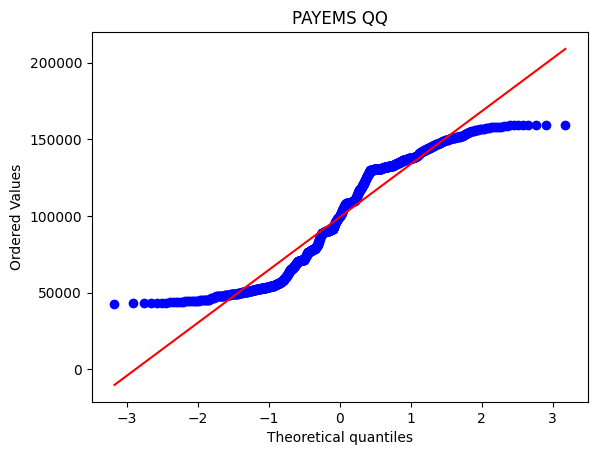

In [2]:
### Data Analysis

import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import stats

df = pd.read_csv("PAYEMS.csv", parse_dates=["date"]).sort_values("date")

col = "PAYEMS"
x = pd.to_numeric(df[col], errors="coerce").dropna().astype(float)

# stats
Q1, Q3 = x.quantile([0.25, 0.75]); IQR = Q3 - Q1
outliers_iqr = ((x < Q1 - 1.5*IQR) | (x > Q3 + 1.5*IQR)).mean()
print(f"Outlier rate (IQR): {outliers_iqr:.1%}")
print(f"skew={stats.skew(x, bias=False):.2f}, kurtosis={stats.kurtosis(x, fisher=True, bias=False):.2f}")

# plots
plt.figure(); plt.hist(x, bins=40); plt.title(col)
plt.figure(); stats.probplot(x, dist="norm", plot=plt); plt.title(col + " QQ")
plt.show()

In [3]:
### Min Max Scaling and Reformatting Data for ML 

y_all = df[col]

# reshape data into X and y (X predicts y)
L = 12
y_all = df[col].to_numpy(dtype=float)
X = np.array([y_all[i-L:i] for i in range(L, len(y_all))])   # (N, L)
y = np.array([y_all[i]     for i in range(L, len(y_all))])   # (N,)

print("X:", X.shape)
print("y:", y.shape)

#seperate into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2, shuffle=False)

#min max scaling designed to fit X_train
X_scaler = MinMaxScaler()
X_train_scaled  = X_scaler.fit_transform(X_train)
X_test_scaled  = X_scaler.transform(X_test)

y_scaler = MinMaxScaler()
y_train_scaled  = y_scaler.fit_transform(y_train.reshape(-1, 1)).ravel()
y_test_scaled  = y_scaler.transform(y_test.reshape(-1, 1)).ravel()

#reformat for LSTM
X_train_scaled = X_train_scaled.reshape((-1, L, 1))
X_test_scaled  = X_test_scaled.reshape((-1, L, 1))

print("X_train:", X_train_scaled.shape)
print("X_test:", X_test_scaled.shape)
print("y_train:", y_train_scaled.shape)
print("y_test:", y_test_scaled.shape)

X: (920, 12)
y: (920,)
X_train: (736, 12, 1)
X_test: (184, 12, 1)
y_train: (736,)
y_test: (184,)


In [4]:
### Function for Plotting Training History

def plot_history(history):
    """Plots MSE for training/validation over epochs."""
    import matplotlib.pyplot as plt
    h = history.history

    plt.figure()
    plt.plot(h["loss"], label="train MSE")
    if "val_loss" in h:
        plt.plot(h["val_loss"], label="val MSE")
    plt.xlabel("Epoch")
    plt.ylabel("MSE")
    plt.title("Training vs Validation MSE")
    plt.legend()
    plt.grid(True)
    plt.show()

Epoch 1/30
23/23 [==============================] - 2s 28ms/step - loss: 0.2045 - val_loss: 0.6340
Epoch 2/30
23/23 [==============================] - 0s 7ms/step - loss: 0.1621 - val_loss: 0.5071
Epoch 3/30
23/23 [==============================] - 0s 6ms/step - loss: 0.1244 - val_loss: 0.3865
Epoch 4/30
23/23 [==============================] - 0s 6ms/step - loss: 0.0890 - val_loss: 0.2775
Epoch 5/30
23/23 [==============================] - 0s 6ms/step - loss: 0.0580 - val_loss: 0.1787
Epoch 6/30
23/23 [==============================] - 0s 7ms/step - loss: 0.0328 - val_loss: 0.0972
Epoch 7/30
23/23 [==============================] - 0s 6ms/step - loss: 0.0154 - val_loss: 0.0438
Epoch 8/30
23/23 [==============================] - 0s 6ms/step - loss: 0.0069 - val_loss: 0.0170
Epoch 9/30
23/23 [==============================] - 0s 6ms/step - loss: 0.0042 - val_loss: 0.0083
Epoch 10/30
23/23 [==============================] - 0s 6ms/step - loss: 0.0036 - val_loss: 0.0059
Epoch 11/30
23/23 

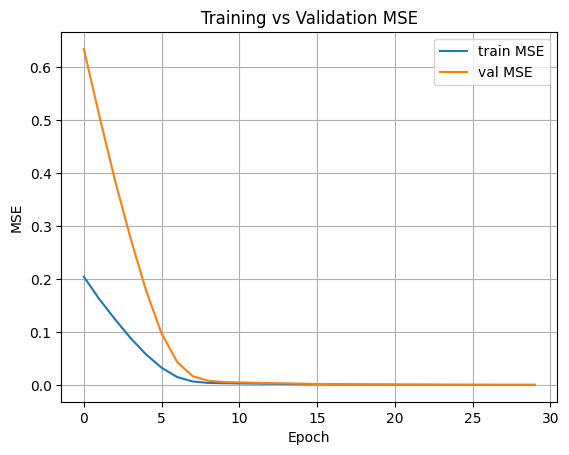

In [5]:
### Create Neural Network

import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor

hidden_units = 32
batch_size = 32
epochs = 30
l1 = 1e-3
lr = 1e-4

opt = Adam(learning_rate=lr)


model = Sequential([
    LSTM(hidden_units, input_shape=(L,1)),
    Dense(1)
])

model.compile(optimizer=opt, loss="mse")

history = model.fit(X_train_scaled, 
                    y_train_scaled, 
                    validation_data=(X_test_scaled, y_test_scaled), 
                    batch_size=batch_size, 
                    epochs=epochs)

plot_history(history)


In [6]:
### Get Predictions

y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

6/6 [==============================] - 0s 4ms/step


In [7]:
### Measuring Performance

train_mse = mean_squared_error(y_train_scaled, y_train_pred)
train_r2 = r2_score(y_train_scaled, y_train_pred)

test_mse = mean_squared_error(y_test_scaled, y_test_pred)
test_r2 = r2_score(y_test_scaled, y_test_pred)

print("train_mse:", train_mse)
print("train_r2:", train_r2)
print("test_mse:", test_mse)
print("test_r2:", test_r2)

train_mse: 0.00042413817404950415
train_r2: 0.9957944101658702
test_mse: 0.0006846685349370767
test_r2: 0.9166912476965541


6/6 [==============================] - 0s 3ms/step
[0.9229148  0.92260957 0.9226299  0.922777   0.923026   0.92331254
 0.92391115 0.9246584  0.92558944 0.9264917 ]


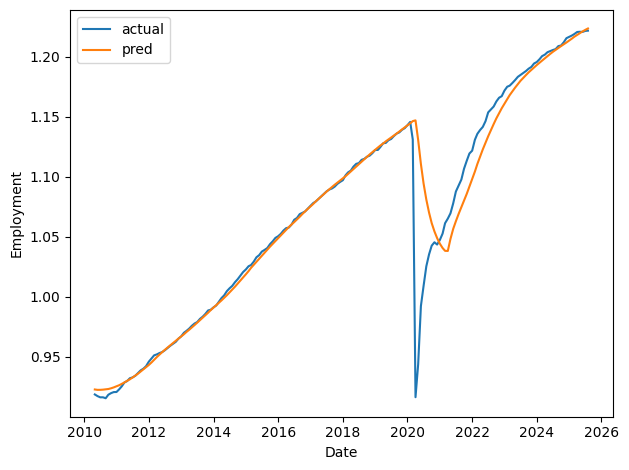

In [8]:
# Returns Predictions on Test Data

y_pred = model.predict(X_test_scaled).ravel()   # make sure it's 1-D
print(y_pred[:10])

test_dates = df["date"].iloc[-len(y_test):].to_numpy()

import matplotlib.pyplot as plt
plt.plot(test_dates, y_test_scaled, label="actual")
plt.plot(test_dates, y_pred, label="pred")
plt.xlabel("Date"); plt.ylabel("Employment"); plt.legend(); plt.tight_layout()
plt.show()

In [9]:
# Predicts Three Months in the Future

L = 12
window = df["PAYEMS"].to_numpy(dtype=float)[-L:].copy()   # last L values in ORIGINAL units
preds = []

for _ in range(3):  # next 3 steps
    X_scaled = X_scaler.transform(window.reshape(1, L))    # (1, L) scaled with TRAIN-fitted scaler
    X_scaled = X_scaled.reshape(1, L, 1)                   # LSTM expects (batch, timesteps, features)
    y_hat_scaled = model.predict(X_scaled)                 # scaled prediction (shape (1,) or (1,1))
    y_hat = y_scaler.inverse_transform(
        np.asarray(y_hat_scaled).reshape(-1, 1)
    ).ravel()[0]                                           # back to ORIGINAL units → scalar
    preds.append(y_hat)
    window = np.append(window[1:], y_hat)                  # slide window forward with prediction

dates = pd.date_range(df["date"].iloc[-1] + pd.offsets.MonthBegin(1), periods=len(preds), freq="MS")
print(pd.DataFrame({"date": dates, "pred": np.array(preds, dtype=float)}).to_string(index=False))


1/1 [==============================] - 0s 20ms/step
      date          pred
2025-09-01 159817.640625
2025-10-01 159923.609375
2025-11-01 160034.671875
